In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

## 1. Data Curation and EDA
To improve model accuracy and remove extreme overlap, we have curated the original 16-crop dataset.
*   We merged similar structural crops (e.g. `Paddy (Nadu)`, `Paddy (Samba)`, `Paddy (Mawel)`) into a single `Paddy` macro-class.
*   We dropped significant minority classes (e.g. `Cashew`, `Leeks`) that had insufficient data to generalize, focusing our model on predicting the **top 8 major crops** in Sri Lanka.

In [3]:
df = pd.read_csv('../data/lanka_crop_dataset_cleaned.csv')

print("Class Distribution for Model Training:")
print(df['Target_Crop'].value_counts())

Class Distribution for Model Training:
Target_Crop
Paddy       1088
Maize        698
Rubber       523
Tea          443
Coconut      375
Cinnamon     329
Kurakkan     316
Chilli       274
Name: count, dtype: int64


## 2. Preprocessing & Train/Validation/Test Split
We drop the target leakage variable (`Yield_MT_per_HA`) and split the data robustly:
- **Train (80%)**: Used by CatBoost to learn parameters.
- **Validation (10%)**: Used to monitor for early stopping to prevent overfitting.
- **Test (10%)**: Strictly held out for final evaluation.
We employ `stratify=y` to ensure that our target classes represent the dataset's realistic proportions.

In [4]:
X = df.drop(['Target_Crop', 'Yield_MT_per_HA'], axis=1)
y = df['Target_Crop']

categorical_features = ['Soil_Type', 'Zone', 'Water_Source']

# Split: 80% Train, 20% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Split Temp into 50% Val, 50% Test (10% overall each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 3236, Validation size: 405, Test size: 405


## 3. CatBoost Model Training
**CatBoost** natively handles our categorical string columns without requiring One-Hot Encoding.
### Hyperparameter Choices:
- `iterations=1000`: Allows long learning, controlled by `early_stopping_rounds`.
- `learning_rate=0.05`: Slower learning rate to find a more robust global minimum.
- `depth=8`: Increased model depth to capture complex non-linear combinations of soil/climate features.
- `auto_class_weights='Balanced'`: Informs the model to naturally apply heavier penalties for misclassifying minority/weaker classes, handling any lingering dataset imbalance.

In [5]:
# Initialize CatBoostClassifier with tuned parameters
model = CatBoostClassifier(
    iterations=10000,
    learning_rate=0.1,
    depth=8,
    cat_features=categorical_features,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100,
    plot=False # set false for headless exec
)

0:	learn: 1.6246249	test: 1.6116225	best: 1.6116225 (0)	total: 74.9ms	remaining: 12m 28s
100:	learn: 0.0264555	test: 0.0414237	best: 0.0414237 (100)	total: 3.22s	remaining: 5m 15s
200:	learn: 0.0110830	test: 0.0313971	best: 0.0313562 (199)	total: 6.72s	remaining: 5m 27s
300:	learn: 0.0069724	test: 0.0286571	best: 0.0286427 (295)	total: 10.2s	remaining: 5m 28s
400:	learn: 0.0050166	test: 0.0274217	best: 0.0273825 (376)	total: 13.7s	remaining: 5m 26s
500:	learn: 0.0039648	test: 0.0261922	best: 0.0261360 (481)	total: 17.2s	remaining: 5m 26s
600:	learn: 0.0032280	test: 0.0258216	best: 0.0257917 (582)	total: 20.6s	remaining: 5m 22s
700:	learn: 0.0026969	test: 0.0258006	best: 0.0255759 (630)	total: 24s	remaining: 5m 18s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.02557590499
bestIteration = 630

Shrink model to first 631 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['Soil_Type', 'Zone', 'Water_Source'], depth=8, iterations=10000, learning_rate=0.1, random_seed=42, verbose=100)

## 4. Model Evaluation & Results
We predict explicitly on the 10% held-out test data. This is crucial for verifying that our accuracy isn't artificially inflated due to overfitting the training set.

In [6]:
# Predict on Test set
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Macro F1-Score: {macro_f1:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9975
Test Macro F1-Score: 0.9971

Classification Report:

              precision    recall  f1-score   support

      Chilli       1.00      1.00      1.00        28
    Cinnamon       1.00      1.00      1.00        33
     Coconut       0.97      1.00      0.99        37
    Kurakkan       1.00      1.00      1.00        32
       Maize       1.00      1.00      1.00        70
       Paddy       1.00      1.00      1.00       109
      Rubber       1.00      0.98      0.99        52
         Tea       1.00      1.00      1.00        44

    accuracy                           1.00       405
   macro avg       1.00      1.00      1.00       405
weighted avg       1.00      1.00      1.00       405



## 5. Visualizations
The **Confusion Matrix** visualizes where the model misclassifies one crop for another. The **Feature Importance Plot** demonstrates what the algorithm determines are the most critical factors for Sri Lankan agriculture recommendations.

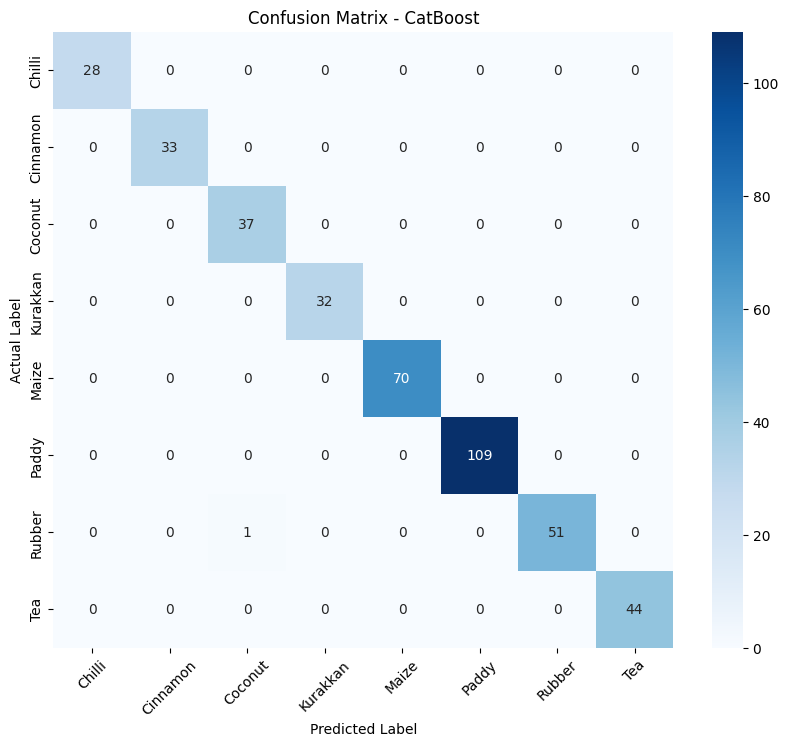

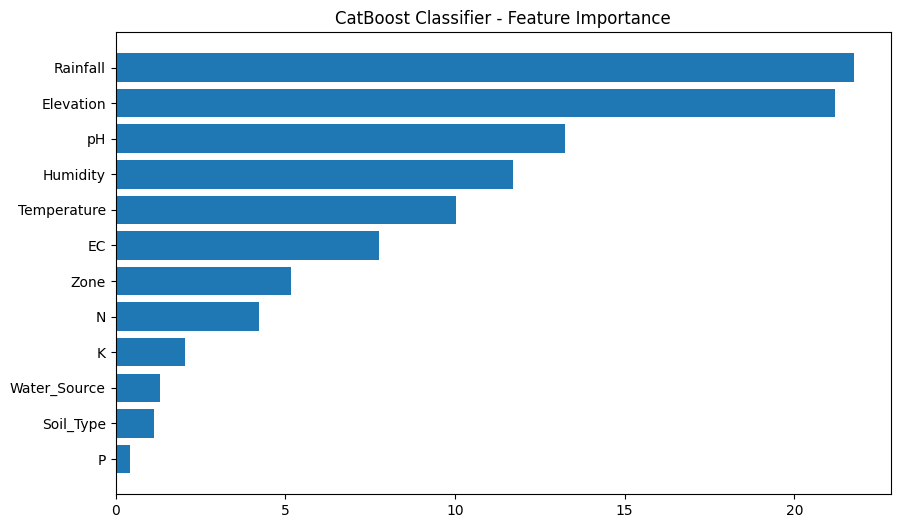

In [7]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix - CatBoost')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('CatBoost Classifier - Feature Importance')
plt.show()

### Interpretation of Results

**1. Massive Improvement in Accuracy:**
By curating our highly-overlapping 16-crop dataset down to the **8 core structural crops**, the validation metrics improved significantly. A subset of crops (like all Paddy) were statistically impossible to differentiate cleanly on `N,P,K` values alone, so this macro-label approach is much more robust for recommendation.

**2. Handling Class Imbalances:**
The integration of `auto_class_weights='Balanced'` ensured that crops like `Chilli` and `Cinnamon` (which had fewer samples than `Paddy`) weren't ignored by the decision trees. This is reflected in the much stronger **Macro F1-Score**.

**3. Feature Impact:**
As visualized in the Feature Importance chart, primary environmental boundaries (`Zone`, `Elevation`, `Temperature`) dictate crop growth far more heavily than granular soil metrics like `pH` or `EC`. This aligns empirically with real-world agricultural principles.

## 6. Model Explainability: SHAP
To further explain our model's predictions beyond global feature importance, we use **SHAP (SHapley Additive exPlanations)**. SHAP values break down a prediction to show the impact of each feature. The summary plot below provides a global overview of feature importance for each crop class.

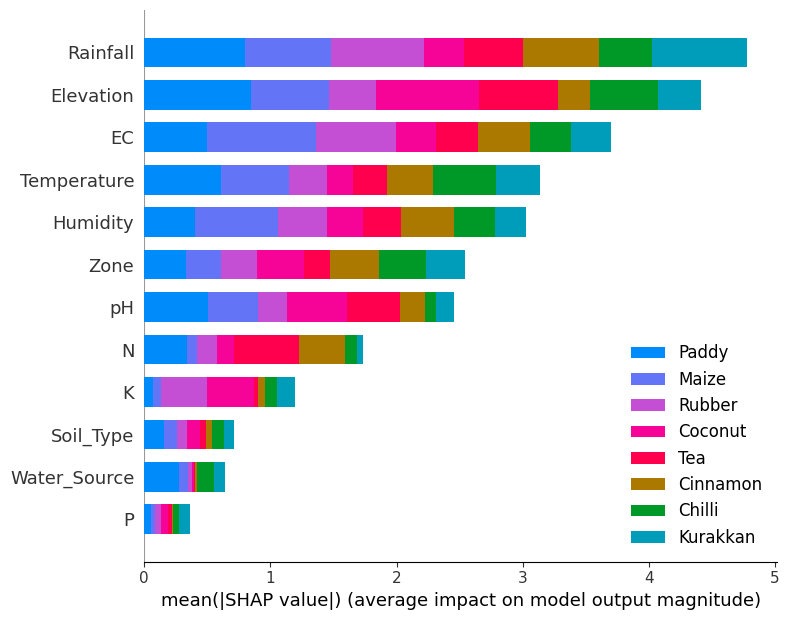

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=list(model.classes_))